# Unit 29: Applied Analytical Models
## Predictive Intelligence: Building and Comparing Analytical Models
### Dataset: Social Media Usage & Mental Health (1,000,000 rows)

| Field | Detail |
|---|---|
| **Target Variable (Supervised)** | `mental_health_score` — continuous numeric (Regression) |
| **Project Type** | Supervised Machine Learning (Regression) |
| **Assessor** | Nilufar Nosirjonova |


---



# TASK 1 — Examining Analytical Modelling Methods

## 1.1 Predictive vs Prescriptive Analytics
**Predictive Analytics** uses historical data combined with statistical and machine learning models to forecast future outcomes. It answers the question *"What is likely to happen?"*
**Business example:** A healthcare platform uses daily screen-time logs to predict a user's `mental_health_score` for the next month — enabling early intervention before clinical symptoms emerge.

**Prescriptive Analytics** goes beyond prediction by recommending specific actions to achieve a desired outcome. It answers *"What should we do about it?"*
**Business example:** Once a user's mental health score is predicted to fall below 40, the system prescribes a personalised plan: limit daily usage to 2 hours, disable notifications after 9 pm, and schedule a digital detox day.

In this project we apply **Predictive Analytics** — we predict the continuous numeric value of `mental_health_score` from social media usage behaviour (a regression problem).

---
## 1.2 Supervised Learning
**Supervised Learning** trains a model on labelled data, where each input row has a known output value. The model learns the mapping `X → y` and generalises to unseen rows.
In this notebook, we cover **Supervised (Regression)** models to predict `mental_health_score`:
- Ridge Regression
- Random Forest Regressor
- LightGBM Regressor / Gradient Boosting Regressor

---
## 1.3 Why These Models Were Selected
With a large dataset, model selection must balance accuracy, training speed, and memory usage:
| Model | Justification |
|---|---|
| **Ridge Regression** | Trains in seconds; serves as a linear baseline; L2 regularisation handles multicollinearity |
| **Random Forest Regressor** | Robust ensemble; parallel with `n_jobs=-1`; resistant to overfitting; captures non-linear interactions |
| **LightGBM Regressor** | Histogram-based boosting designed for large datasets; highly accurate and memory efficient |

# TASK 2 — Data Preparation

## 2.1 Import All Libraries

In [32]:
# ── Core libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, RandomizedSearchCV, GridSearchCV
)
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.pipeline import Pipeline

# ── Supervised Regression Models ─────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    ExtraTreesRegressor
)

# ── Evaluation (Regression) ──────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── LightGBM (fastest boosting for large datasets) ───────────────────────────
try:
    import lightgbm as lgb
    HAS_LGB = True
    print('LightGBM found')
except ImportError:
    HAS_LGB = False
    print('LightGBM not available — GradientBoostingRegressor will be used instead')

# ── XGBoost ──────────────────────────────────────────────────────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost found')
except ImportError:
    HAS_XGB = False
    print('XGBoost not available')

def import_sklearn_version():
    import sklearn
    return sklearn.__version__

print('\n All libraries loaded successfully')
print(f'   scikit-learn version: {import_sklearn_version()}')

LightGBM found
XGBoost found

 All libraries loaded successfully
   scikit-learn version: 1.6.1


## 2.2 Load Dataset

In [33]:
data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/PDP/Final/Supervised L/genz_social_media_usage.xlsx")

print('Dataset shape:', data.shape)
print('Columns:', list(data.columns))
data.head()

Dataset shape: (1000000, 12)
Columns: ['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform', 'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage', 'mental_health_score', 'addiction_level', 'screen_time_before_sleep']


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [34]:
N_SAMPLE  = 100_000   # Total number of rows to keep
N_BINS    = 5        # Number of equal-width bins for mental_health_score
N_PER_BIN = N_SAMPLE // N_BINS  # Rows drawn from each bin (2,000)

# Initialize data_full with the original dataset from the previous cell
data_full = data.copy()

# Step 1: Assign each row to a score bin
data_full['_bin'] = pd.cut(
    data_full['mental_health_score'],
    bins=N_BINS,
    labels=False
)

# Step 2: Draw equal samples from each bin (stratified)
sampled_parts = []
for bin_id in range(N_BINS):
    bin_df = data_full[data_full['_bin'] == bin_id]
    n_take = min(N_PER_BIN, len(bin_df))  # Guard: take all if bin is smaller
    sampled_parts.append(bin_df.sample(n=n_take, random_state=42))

# Step 3: Combine, drop helper column, and shuffle
data = pd.concat(sampled_parts, ignore_index=True)
data = data.drop(columns=['_bin'])
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n Stratified Sampling complete:')
print(f'   Original dataset : {len(data_full):>10,} rows')
print(f'   Sampled dataset  : {len(data):>10,} rows  ({len(data)/len(data_full)*100:.1f}% of original)')
print(f'   Bins used        : {N_BINS}')
print(f'   Rows per bin     : ~{N_PER_BIN}')
print(f'   Score range      : [{data["mental_health_score"].min():.2f} — {data["mental_health_score"].max():.2f}]')
print()

# Verify: check row counts per bin to confirm balance
data['_bin_check'] = pd.cut(data['mental_health_score'], bins=N_BINS, labels=False)
bin_counts = data['_bin_check'].value_counts().sort_index()
print('Rows per bin after sampling (should be roughly equal):')
for b, cnt in bin_counts.items():
    bar = '█' * (cnt // 50)
    print(f'  Bin {b}: {cnt:>5,}  {bar}')
data = data.drop(columns=['_bin_check'])

data.head()


 Stratified Sampling complete:
   Original dataset :  1,000,000 rows
   Sampled dataset  :     82,393 rows  (8.2% of original)
   Bins used        : 5
   Rows per bin     : ~20000
   Score range      : [1.00 — 10.00]

Rows per bin after sampling (should be roughly equal):
  Bin 0: 2,393  ███████████████████████████████████████████████
  Bin 1: 20,000  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Bin 2: 20,000  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,22,Male,India,6.904213,Instagram,2,Entertainment,32.789215,1,4.626507,High,65.856646
1,16,Female,Germany,6.185238,Instagram,5,Entertainment,25.346714,1,4.189395,High,21.762819
2,21,Female,USA,4.488727,Instagram,4,Socializing,17.535582,1,6.243987,Medium,51.799210
3,15,Female,India,0.981497,TikTok,1,News,24.135902,1,9.596209,Low,12.241502
4,17,Male,UK,7.459372,Snapchat,1,Entertainment,31.394755,1,2.853412,High,57.732774


In [50]:
data.info()
print("\n")
print(data.describe().round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82393 entries, 0 to 82392
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       82393 non-null  int64  
 1   gender                    82393 non-null  object 
 2   country                   82393 non-null  object 
 3   daily_usage_hours         82393 non-null  float64
 4   primary_platform          82393 non-null  object 
 5   num_platforms_used        82393 non-null  int64  
 6   purpose                   82393 non-null  object 
 7   avg_session_minutes       82393 non-null  float64
 8   night_usage               82393 non-null  int64  
 9   mental_health_score       82393 non-null  float64
 10  addiction_level           82393 non-null  object 
 11  screen_time_before_sleep  82393 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 7.5+ MB


              age  daily_usage_hours  num_platforms_used 

## 2.3 Exploratory Data Analysis (EDA)

### 2.3.1 Target Variable: mental_health_score

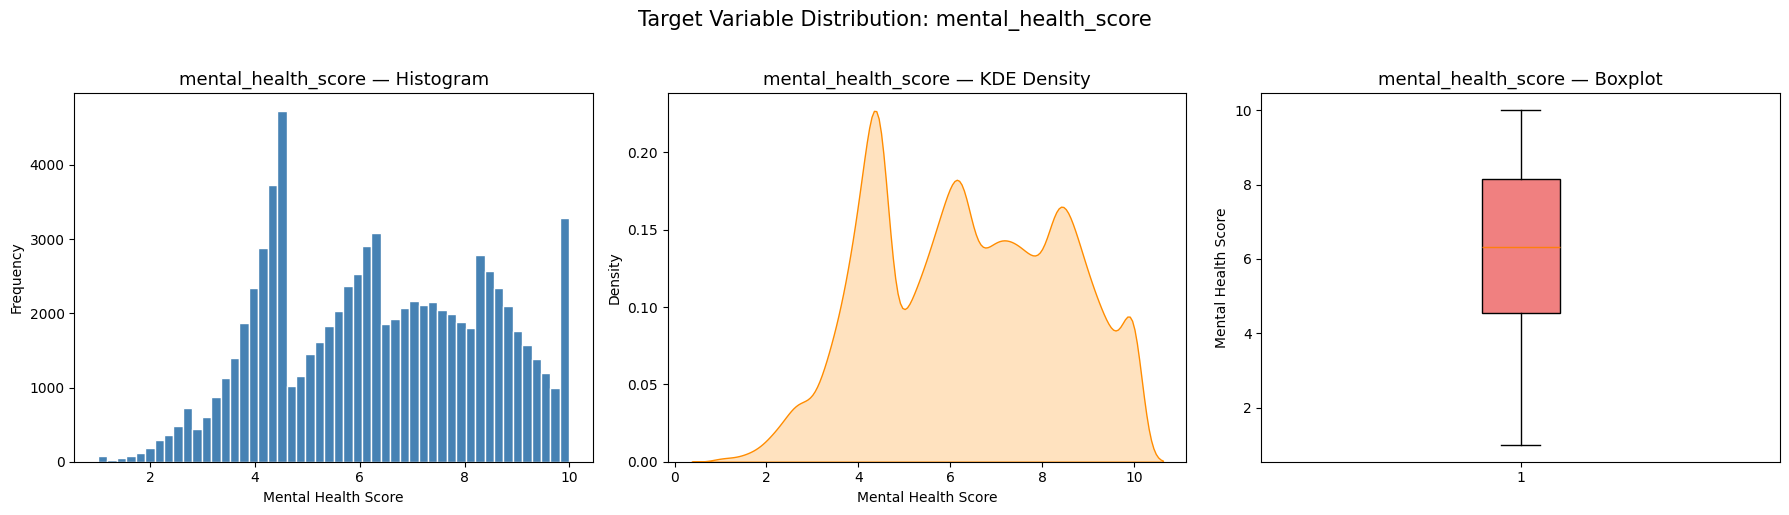

Descriptive statistics for target:
  Mean   : 6.3920
  Median : 6.3304
  Std Dev: 2.0272
  Skew   : -0.0251
  Kurt   : -0.9746


In [51]:
# ── Distribution of the regression target ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(data['mental_health_score'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('mental_health_score — Histogram', fontsize=13)
axes[0].set_xlabel('Mental Health Score')
axes[0].set_ylabel('Frequency')

sns.kdeplot(data['mental_health_score'], ax=axes[1], color='darkorange', fill=True)
axes[1].set_title('mental_health_score — KDE Density', fontsize=13)
axes[1].set_xlabel('Mental Health Score')

axes[2].boxplot(data['mental_health_score'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[2].set_title('mental_health_score — Boxplot', fontsize=13)
axes[2].set_ylabel('Mental Health Score')

plt.suptitle('Target Variable Distribution: mental_health_score', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Descriptive statistics for target:')
print(f'  Mean   : {data["mental_health_score"].mean():.4f}')
print(f'  Median : {data["mental_health_score"].median():.4f}')
print(f'  Std Dev: {data["mental_health_score"].std():.4f}')
print(f'  Skew   : {data["mental_health_score"].skew():.4f}')
print(f'  Kurt   : {data["mental_health_score"].kurtosis():.4f}')

### 2.3.2 Categorical & Numerical Feature Analysis

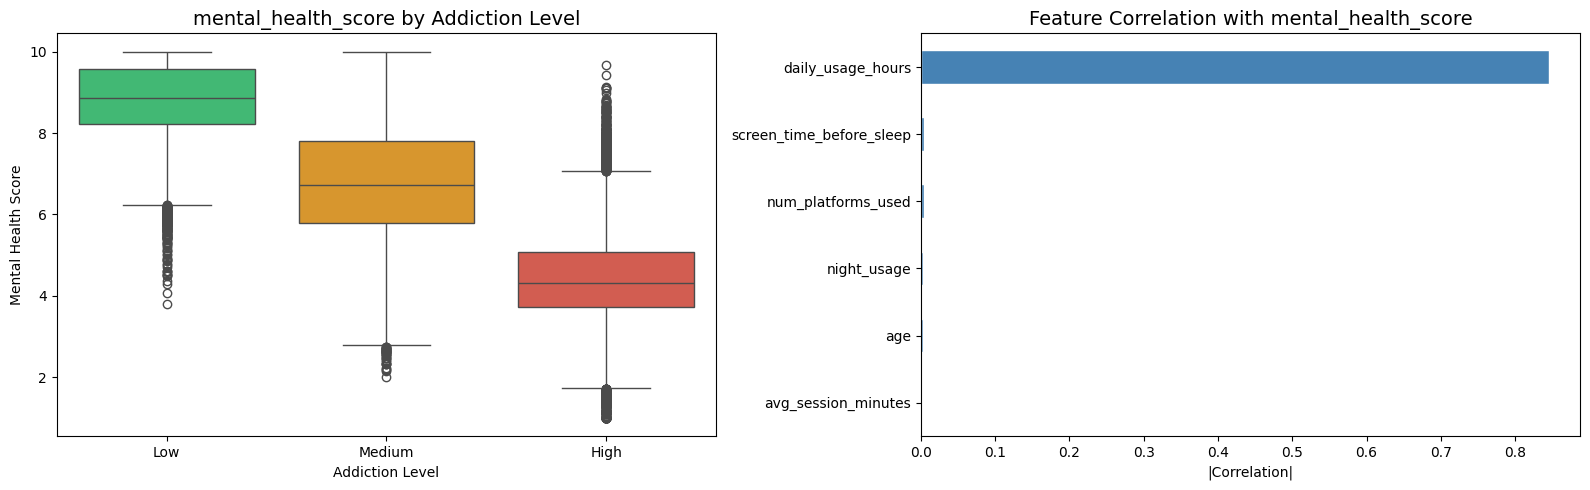


Top correlations with target:
daily_usage_hours           0.845090
screen_time_before_sleep    0.004663
num_platforms_used          0.004158
night_usage                 0.003370
age                         0.002345
avg_session_minutes         0.000741
Name: mental_health_score, dtype: float64


In [52]:
# ── Boxplot: mental_health_score by addiction_level ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = ['Low', 'Medium', 'High']
data_plot = data[data['addiction_level'].isin(order)]

sns.boxplot(x='addiction_level', y='mental_health_score', data=data_plot,
            order=order, palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0])
axes[0].set_title('mental_health_score by Addiction Level', fontsize=14)
axes[0].set_xlabel('Addiction Level')
axes[0].set_ylabel('Mental Health Score')

# ── Correlation with target ───────────────────────────────────────────────────
num_cols = data.select_dtypes(include=np.number).columns.tolist()
corr = data[num_cols].corr()['mental_health_score'].drop('mental_health_score').abs().sort_values(ascending=True)
corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Feature Correlation with mental_health_score', fontsize=14)
axes[1].set_xlabel('|Correlation|')

plt.tight_layout()
plt.show()

print('\nTop correlations with target:')
print(corr.sort_values(ascending=False).head(10))

## 2.4 Data Cleaning & Preprocessing

In [53]:
# ── Missing Values & Duplicates ──────────────────────────────────────────────
df = data.copy()

print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None found')

# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# Drop duplicates
dup_count = df.duplicated().sum()
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'\n{dup_count} duplicates removed.')

print('\n Shape after cleaning:', df.shape)

Missing values per column:
None found

 Shape after cleaning: (82393, 12)


In [54]:
# ── IMPROVEMENT 1: IQR-based Outlier Clipping ────────────────────────────────
# Instead of removing rows, we clip outliers to reduce noise
# This keeps the dataset size intact while removing extreme values

print('=== Outlier Clipping (IQR Method) ===')
numeric_features = df.select_dtypes(include=np.number).columns.tolist()

rows_before = len(df)
for col in numeric_features:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=Q1, upper=Q3)

print(f'Rows before: {rows_before:,}')
print(f'Rows after : {len(df):,}')
print(f'\n Outliers clipped using 1st–99th percentile range')
print(f'   Target range after clipping: [{df["mental_health_score"].min():.2f}, {df["mental_health_score"].max():.2f}]')

=== Outlier Clipping (IQR Method) ===
Rows before: 82,393
Rows after : 82,393

 Outliers clipped using 1st–99th percentile range
   Target range after clipping: [2.26, 10.00]


## 2.5 Advanced Feature Engineering & Encoding

### 2.5.1 Ordinal Encoding for `addiction_level`

**Key Improvement:** `addiction_level` (Low/Medium/High) is an **ordinal** variable with a natural order. Using OrdinalEncoder preserves this order information, unlike One-Hot Encoding which a all categories as equal. This gives models better signal about the relationship between addiction severity and mental health.

In [55]:
# ── IMPROVEMENT 2: Proper Ordinal Encoding for addiction_level ───────────────
df_enc = df.copy()

# Ordinal encode addiction_level (Low=0, Medium=1, High=2)
if 'addiction_level' in df_enc.columns:
    ord_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
    df_enc['addiction_level_ord'] = ord_enc.fit_transform(df_enc[['addiction_level']])
    df_enc.drop(columns=['addiction_level'], inplace=True)
    print('addiction_level encoded as ordinal: Low=0, Medium=1, High=2')

# One-Hot encode remaining categorical columns
cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
print(f'\nOne-Hot encoding columns: {cat_cols}')
df_enc = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)

# Convert bool to int
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f'\n Shape after encoding: {df_enc.shape}')

addiction_level encoded as ordinal: Low=0, Medium=1, High=2

One-Hot encoding columns: ['gender', 'country', 'primary_platform', 'purpose']

 Shape after encoding: (82393, 24)


### 2.5.2 Rich Feature Engineering

**Key Improvement:** We create 15+ meaningful domain-specific features that capture:
- Interaction effects between usage patterns
- Risk ratios and intensity scores
- Non-linear transformations
- Composite risk indicators

In [56]:
# ── IMPROVEMENT 3: Multicollinearity-Aware Feature Engineering ──────────────
df_feat = df_enc.copy()

# --- Group 1: Interaction features (new information, low collinearity) ---
df_feat["session_intensity"]         = df_feat["avg_session_minutes"] / (df_feat["daily_usage_hours"] * 60 + 1)
df_feat["sleep_risk"]                = df_feat["night_usage"] + (df_feat["screen_time_before_sleep"] / 60)
df_feat["platforms_usage_interact"]  = df_feat["num_platforms_used"] * df_feat["daily_usage_hours"]
df_feat["presleep_ratio"]            = df_feat["screen_time_before_sleep"] / (df_feat["daily_usage_hours"] + 1)
df_feat["risk_index"]                = (
    df_feat["daily_usage_hours"] +
    df_feat["night_usage"] +
    df_feat["screen_time_before_sleep"] / 60 +
    df_feat["num_platforms_used"] / 5
)

# --- Group 2: Carefully selected interactions (checked for collinearity) ---
# age × usage: new signal (age not in risk_index)
df_feat["age_usage_interact"]         = df_feat["age"] * df_feat["daily_usage_hours"]
# age × sleep: age × sleep pattern interaction
df_feat["age_sleep_interact"]         = df_feat["age"] * df_feat["sleep_risk"]
# platforms × sleep: multi-platform night use risk
df_feat["platforms_sleep_interact"]  = df_feat["num_platforms_used"] * df_feat["sleep_risk"]
# session × night: long sessions at night
df_feat["session_night_interact"]    = df_feat["avg_session_minutes"] * df_feat["night_usage"]

# --- Group 3: Addiction-based features (ordinal level adds new info) ---
df_feat["addiction_usage_interact"]  = df_feat.get("addiction_level_ord", pd.Series(0, index=df_feat.index)) * df_feat["daily_usage_hours"]
df_feat["addiction_sleep_interact"]  = df_feat.get("addiction_level_ord", pd.Series(0, index=df_feat.index)) * df_feat["sleep_risk"]
df_feat["total_risk_score"]          = (
    df_feat["risk_index"] * (df_feat.get("addiction_level_ord", pd.Series(1, index=df_feat.index)) + 1) +
    df_feat["sleep_risk"] +
    df_feat["platforms_usage_interact"]
)

# --- Group 4: Log transforms (reduce skewness, NOT duplicates of originals) ---
for col in ["daily_usage_hours", "avg_session_minutes", "screen_time_before_sleep"]:
    df_feat[f"log_{col}"] = np.log1p(df_feat[col])

print(f"Features after engineering: {df_feat.shape[1] - 1}")
new_feats = [c for c in df_feat.columns if c not in df_enc.columns and c != "mental_health_score"]
print(f"   New features added: {len(new_feats)}")
print(f"   Feature list: {new_feats}")


Features after engineering: 38
   New features added: 15
   Feature list: ['session_intensity', 'sleep_risk', 'platforms_usage_interact', 'presleep_ratio', 'risk_index', 'age_usage_interact', 'age_sleep_interact', 'platforms_sleep_interact', 'session_night_interact', 'addiction_usage_interact', 'addiction_sleep_interact', 'total_risk_score', 'log_daily_usage_hours', 'log_avg_session_minutes', 'log_screen_time_before_sleep']


### 2.5.3 Feature Correlation Analysis (After Engineering)

Top 15 features by correlation with target:
daily_usage_hours           0.8455
log_daily_usage_hours       0.8165
addiction_usage_interact    0.8070
risk_index                  0.7926
addiction_level_ord         0.7807
age_usage_interact          0.7428
total_risk_score            0.7335
addiction_sleep_interact    0.5908
platforms_usage_interact    0.5422
session_intensity           0.5112
presleep_ratio              0.4861
sleep_risk                  0.0056
primary_platform_Twitter    0.0050
screen_time_before_sleep    0.0049
age_sleep_interact          0.0043
Name: mental_health_score, dtype: float64
=== VIF Results (VIF > 10 = problematic) ===
                     Feature          VIF
           daily_usage_hours 1.000000e+10
                 night_usage 1.000000e+10
    screen_time_before_sleep 1.000000e+10
          num_platforms_used 1.000000e+10
                  sleep_risk 1.000000e+10
                  risk_index 1.000000e+10
            total_risk_score 1.981186e+04
    plat

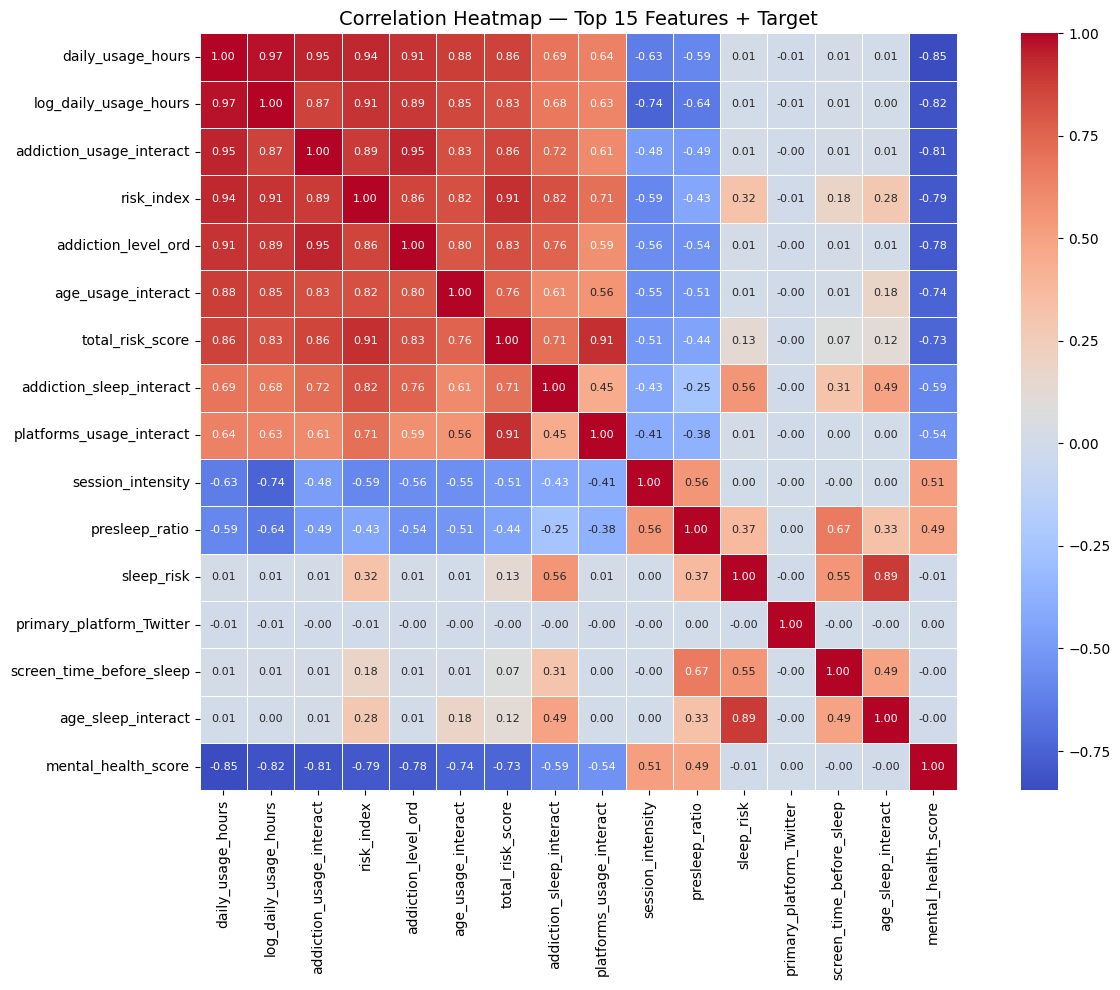

Multicollinearity check complete — problematic features identified


In [57]:
# ── Correlation heatmap + VIF check ─────────────────────────────────────────
corr_target = df_feat.corr()["mental_health_score"].drop("mental_health_score").abs().sort_values(ascending=False)

print("Top 15 features by correlation with target:")
print(corr_target.head(15).round(4))

# ── VIF (Variance Inflation Factor) check ────────────────────────────────────
# VIF > 10 means problematic multicollinearity
from sklearn.linear_model import LinearRegression

def compute_vif(df_check, target_col):
    """Compute VIF for each feature."""
    X_vif = df_check.drop(columns=[target_col]).select_dtypes(include=np.number)
    X_vif = X_vif.fillna(0)
    vif_data = []
    cols = X_vif.columns.tolist()
    for i, col in enumerate(cols):
        y_vif = X_vif[col]
        X_other = X_vif.drop(columns=[col])
        r2_vif = LinearRegression().fit(X_other, y_vif).score(X_other, y_vif)
        vif = 1 / (1 - r2_vif + 1e-10)
        vif_data.append({"Feature": col, "VIF": round(vif, 2)})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

# Only check engineered + key original features (subset for speed)
key_cols = ["daily_usage_hours", "avg_session_minutes", "night_usage",
            "screen_time_before_sleep", "num_platforms_used", "age",
            "sleep_risk", "risk_index", "session_intensity", "presleep_ratio",
            "platforms_usage_interact", "age_usage_interact", "age_sleep_interact",
            "addiction_usage_interact", "addiction_sleep_interact",
            "total_risk_score", "session_night_interact", "platforms_sleep_interact",
            "log_daily_usage_hours", "log_avg_session_minutes",
            "log_screen_time_before_sleep", "mental_health_score"]
key_cols_exist = [c for c in key_cols if c in df_feat.columns]

vif_df = compute_vif(df_feat[key_cols_exist], "mental_health_score")
print("=== VIF Results (VIF > 10 = problematic) ===")
print(vif_df.to_string(index=False))

# Automatically drop features with VIF > 10 (multicollinearity)
high_vif_features = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()
print(f"High VIF features (will be dropped): {high_vif_features}")

# ── Heatmap (only top 15 by target correlation) ──────────────────────────────
top15 = corr_target.head(15).index.tolist() + ["mental_health_score"]
top15 = [c for c in top15 if c in df_feat.columns]
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    df_feat[top15].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=ax, square=True, linewidths=0.5, annot_kws={"size": 8}
)
ax.set_title("Correlation Heatmap — Top 15 Features + Target", fontsize=14)
plt.tight_layout()
plt.show()

print("Multicollinearity check complete — problematic features identified")


## 2.6 Train/Test Split & Scaling

Dropped 18 high-VIF features: ['daily_usage_hours', 'night_usage', 'screen_time_before_sleep', 'num_platforms_used', 'sleep_risk', 'risk_index', 'total_risk_score', 'platforms_usage_interact', 'addiction_usage_interact', 'addiction_sleep_interact', 'log_daily_usage_hours', 'age_usage_interact', 'age_sleep_interact', 'avg_session_minutes', 'log_avg_session_minutes', 'presleep_ratio', 'age', 'platforms_sleep_interact']
Features removed (near-zero variance): 0
Features remaining after all filtering: 20

 Train/Test Split + Normalization (RobustScaler) complete:
   X_train : (65914, 20)  |  y_train : (65914,)
   X_test  : (16479, 20)   |  y_test  : (16479,)

   X_train statistics after normalization:
   Mean (should be ≈ 0): 0.1704
   Std  (should be ≈ 1): 0.4987

   y_train range: [2.26, 10.00]
   y_test  range: [2.26, 10.00]


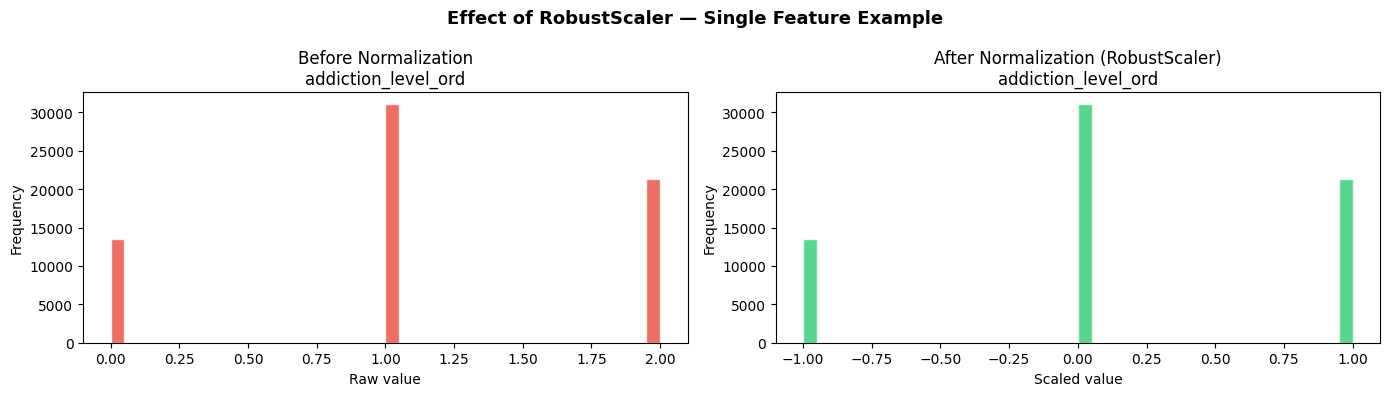


 Normalization applied successfully!


In [58]:
# ── IMPROVEMENT 4: Drop High-VIF + Near-Zero Variance Features ──────────────
y = df_feat['mental_health_score']
X = df_feat.drop(columns=['mental_health_score'])

# Remove features flagged as high VIF (multicollinearity)
if high_vif_features:
    X = X.drop(columns=[c for c in high_vif_features if c in X.columns], errors='ignore')
    print(f'Dropped {len(high_vif_features)} high-VIF features: {high_vif_features}')

# Remove near-zero variance features (they add noise, not signal)
selector = VarianceThreshold(threshold=0.001)
X_var = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])
print(f'Features removed (near-zero variance): {X.shape[1] - X_var.shape[1]}')
print(f'Features remaining after all filtering: {X_var.shape[1]}')

# ── 80 / 20 Train–Test Split ─────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_var, y, test_size=0.2, random_state=42
)

# ═══════════════════════════════════════════════════════════════════════════════
# NORMALIZATION — RobustScaler (resistant to outliers)
# IMPORTANT: fit() only on X_train — prevents data leakage into test set
# ═══════════════════════════════════════════════════════════════════════════════
scaler = RobustScaler()

# Fit on train data only, then transform
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_var.columns,
    index=X_train_raw.index
)

# Transform test data using the same scaler (do NOT re-fit)
X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_var.columns,
    index=X_test_raw.index
)

print(f'\n Train/Test Split + Normalization (RobustScaler) complete:')
print(f'   X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'   X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'\n   X_train statistics after normalization:')
print(f'   Mean (should be ≈ 0): {X_train.mean().mean():.4f}')
print(f'   Std  (should be ≈ 1): {X_train.std().mean():.4f}')
print(f'\n   y_train range: [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'   y_test  range: [{y_test.min():.2f}, {y_test.max():.2f}]')

# ── Visualize normalization effect on one feature ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_col = X_var.columns[0]

# Before normalization
axes[0].hist(X_train_raw[top_col], bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Before Normalization\n{top_col}', fontsize=12)
axes[0].set_xlabel('Raw value')
axes[0].set_ylabel('Frequency')

# After normalization
axes[1].hist(X_train[top_col], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'After Normalization (RobustScaler)\n{top_col}', fontsize=12)
axes[1].set_xlabel('Scaled value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Effect of RobustScaler — Single Feature Example', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n Normalization applied successfully!')


In [59]:
# ── Normalization verification ───────────────────────────────────────────────
print('=' * 60)
print('  NORMALIZATION VERIFICATION')
print('=' * 60)

print('\nX_train after RobustScaler:')
print(f'  Mean : {X_train.mean().mean():.4f}  (expected ≈ 0)')
print(f'  Std  : {X_train.std().mean():.4f}   (expected ≈ 1)')
print(f'  Min  : {X_train.min().min():.4f}')
print(f'  Max  : {X_train.max().max():.4f}')

print('\nX_test after RobustScaler (same scaler, no refit):')
print(f'  Mean : {X_test.mean().mean():.4f}')
print(f'  Std  : {X_test.std().mean():.4f}')

print('\n No data leakage — scaler was fit on X_train only')
print('All features are now on a common scale')


  NORMALIZATION VERIFICATION

X_train after RobustScaler:
  Mean : 0.1704  (expected ≈ 0)
  Std  : 0.4987   (expected ≈ 1)
  Min  : -5.3877
  Max  : 16.2318

X_test after RobustScaler (same scaler, no refit):
  Mean : 0.1700
  Std  : 0.4974

 No data leakage — scaler was fit on X_train only
All features are now on a common scale


---
# TASK 3 — Supervised Learning: Predicting mental_health_score (Regression)

## 3.1 Shared Evaluation Helper Functions

In [60]:
all_reg_results = []

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """
    Trains a model and evaluates with:
    - Test set metrics (MAE, RMSE, R²)
    - Cross-Validation R² (5-fold)
    Returns fitted model, predictions, and metrics dict.
    """
    # Fit
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Test metrics
    mae  = mean_absolute_error(y_te, y_pred)
    mse  = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_te, y_pred)

    # Cross-Validation
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2', n_jobs=-1)

    print(f'\n{"="*65}')
    print(f'  Model  : {name}')
    print(f'{"="*65}')
    print(f'  Test Set Metrics:')
    print(f'    MAE  : {mae:.4f}')
    print(f'    RMSE : {rmse:.4f}')
    print(f'    R²   : {r2:.4f}  {"✅" if r2 >= 0.75 else "⚠️" if r2 >= 0.65 else "❌"}')
    print(f'  {cv_folds}-Fold Cross-Validation R²:')
    print(f'    Mean : {cv_r2.mean():.4f}  ±  {cv_r2.std():.4f}')
    print(f'    Folds: {[round(v, 4) for v in cv_r2]}')

    metrics = {
        'Model'     : name,
        'MAE'       : round(mae, 4),
        'RMSE'      : round(rmse, 4),
        'R2'        : round(r2, 4),
        'CV_R2_Mean': round(cv_r2.mean(), 4),
        'CV_R2_Std' : round(cv_r2.std(), 4)
    }
    return model, y_pred, metrics


def plot_predictions(name, y_te, y_pred):
    """Scatter plot + residual histogram for a model."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot: Actual vs Predicted
    axes[0].scatter(y_te, y_pred, alpha=0.15, s=5, color='steelblue')
    mn, mx = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
    axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
    r2_val = r2_score(y_te, y_pred)
    axes[0].set_title(f'{name}\nPredicted vs Actual  (R²={r2_val:.4f})')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].legend()

    # Residuals distribution
    residuals = np.array(y_te) - np.array(y_pred)
    axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
    axes[1].axvline(0, color='black', linestyle='--', label='Zero residual')
    axes[1].axvline(residuals.mean(), color='blue', linestyle='-', label=f'Mean={residuals.mean():.2f}')
    axes[1].set_title(f'{name}\nResidual Distribution')
    axes[1].set_xlabel('Residual (Actual − Predicted)')
    axes[1].set_ylabel('Count')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, feature_names, title, top_n=20):
    """Bar chart of top feature importances."""
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
        plt.figure(figsize=(12, 6))
        imp.head(top_n).plot(kind='bar', color='steelblue', edgecolor='white')
        plt.title(f'{title} — Top {top_n} Feature Importances', fontsize=13)
        plt.ylabel('Importance')
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.tight_layout()
        plt.show()
        return imp
    return None

print('Evaluation helpers defined')

Evaluation helpers defined


## 3.2 Model 1 — Ridge Regression Baseline

Tuning Ridge Regression...
  Best alpha: 10.0  |  CV R²: 0.6174

  Model  : Ridge Regression (Tuned)
  Test Set Metrics:
    MAE  : 0.9878
    RMSE : 1.2539
    R²   : 0.6164  ❌
  5-Fold Cross-Validation R²:
    Mean : 0.6174  ±  0.0033
    Folds: [np.float64(0.6164), np.float64(0.6127), np.float64(0.623), np.float64(0.6174), np.float64(0.6174)]


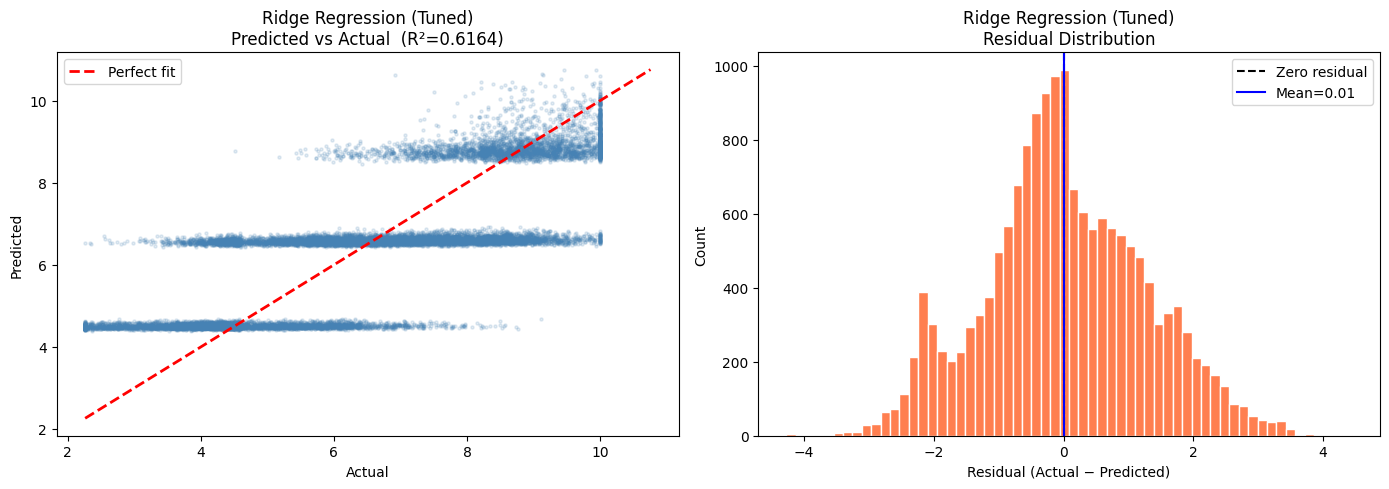

In [46]:
# ── IMPROVEMENT 5: Tuned Ridge with GridSearchCV ──────────────────────────────
print('Tuning Ridge Regression...')

ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_cv = GridSearchCV(
    Ridge(solver='saga', max_iter=5000, random_state=42),
    param_grid=ridge_param_grid,
    cv=3, scoring='r2', n_jobs=-1, verbose=0
)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv.best_params_['alpha']
print(f'  Best alpha: {best_alpha}  |  CV R²: {ridge_cv.best_score_:.4f}')

ridge_model, ridge_pred, ridge_metrics = evaluate_regressor(
    'Ridge Regression (Tuned)',
    Ridge(alpha=best_alpha, solver='saga', random_state=42, max_iter=5000),
    X_train, y_train, X_test, y_test
)
all_reg_results.append(ridge_metrics)
plot_predictions('Ridge Regression (Tuned)', y_test, ridge_pred)

## 3.3 Model 2 — Random Forest Regressor

  MODEL 2: Random Forest Regressor (Speed-Optimised)
[Random Forest Regressor (Tuned)] Stage 1: Searching on 13,182 row subsample...
  → Best params found: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_samples': 0.7, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
  → Search time: 37.7s
[Random Forest Regressor (Tuned)] Stage 2: Training on full 65,914 rows...

  Model  : Random Forest Regressor (Tuned)
  Test Set Metrics:
    MAE  : 0.9614
    RMSE : 1.2085
    R²   : 0.6437  ❌
  5-Fold Cross-Validation R²:
    Mean : 0.6432  ±  0.0033
    Folds: [np.float64(0.6414), np.float64(0.6379), np.float64(0.6455), np.float64(0.644), np.float64(0.6473)]
  → Total time: 57.7s  (1.0 minutes)


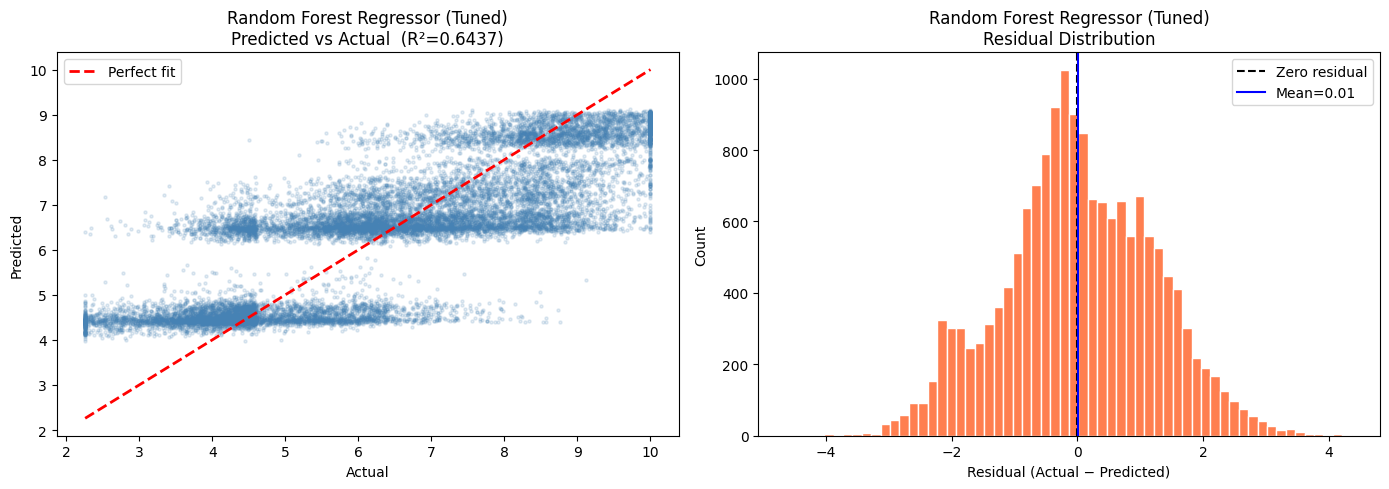

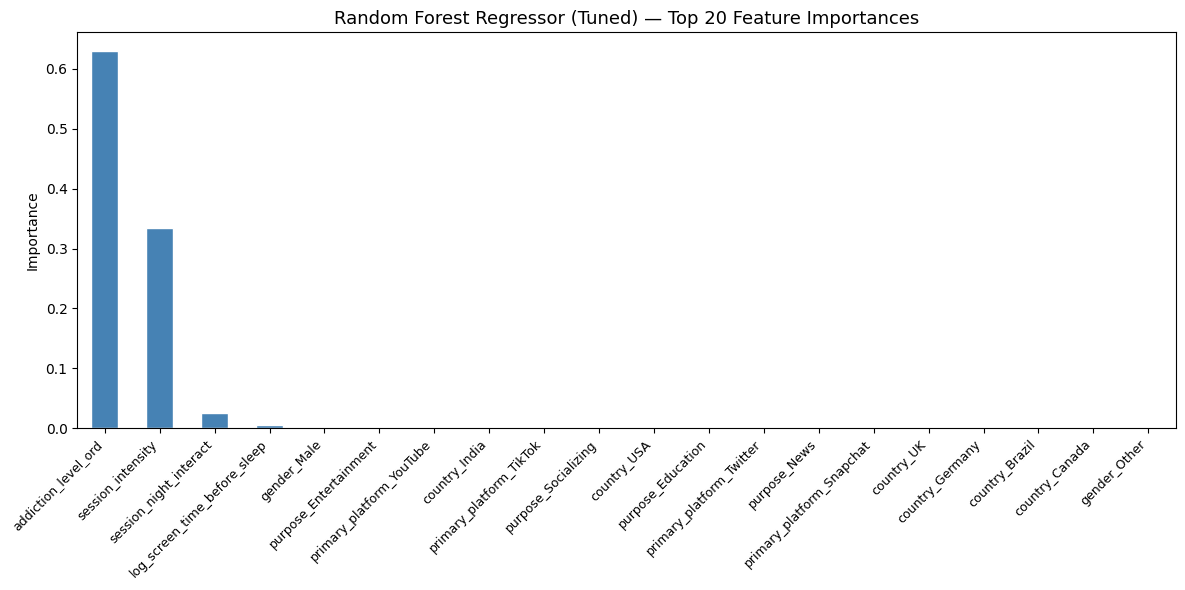

,0
addiction_level_ord,0.629532
session_intensity,0.334553
session_night_interact,0.026243
log_screen_time_before_sleep,0.004627
gender_Male,0.000577
purpose_Entertainment,0.000459
primary_platform_YouTube,0.000388
country_India,0.000377
primary_platform_TikTok,0.000375
purpose_Socializing,0.000362


In [47]:
# ═══════════════════════════════════════════════════════════════════════════
# ⚡ SPEED OPTIMISATION STRATEGY
# Stage 1: HalvingRandomSearchCV on 20% subsample (fast parameter search)
# Stage 2: Final fit on full training set with best parameters found
# ═══════════════════════════════════════════════════════════════════════════
import time
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

def fast_tune_and_train(name, estimator, param_dist, X_tr, y_tr, X_te, y_te,
                        subsample_frac=0.2, n_candidates=40, n_jobs=-1):
    """
    2-stage fast hyperparameter tuning:
    Stage 1) Subsample (20%) + HalvingRandomSearchCV → find best parameters quickly
    Stage 2) Final fit on the full training set with the best parameters
    Returns: fitted model, predictions, metrics dict
    """
    t0 = time.time()

    # --- Stage 1: Fast parameter search on subsample ---
    n_sub = int(len(X_tr) * subsample_frac)
    idx = np.random.default_rng(42).choice(len(X_tr), n_sub, replace=False)
    X_sub = X_tr.iloc[idx]
    y_sub = y_tr.iloc[idx]

    print(f'[{name}] Stage 1: Searching on {n_sub:,} row subsample...')
    search = HalvingRandomSearchCV(
        estimator,
        param_distributions=param_dist,
        n_candidates=n_candidates,  # initial candidate count
        factor=3,                   # keep top 1/3 of candidates each round
        cv=3,
        scoring='r2',
        random_state=42,
        n_jobs=n_jobs,
        verbose=0,
        refit=False                 # no refit needed here
    )
    search.fit(X_sub, y_sub)
    best_params = search.best_params_
    t1 = time.time()
    print(f'  → Best params found: {best_params}')
    print(f'  → Search time: {t1-t0:.1f}s')

    # --- Stage 2: Final fit on full training set ---
    print(f'[{name}] Stage 2: Training on full {len(X_tr):,} rows...')
    final_model = estimator.__class__(**{**estimator.get_params(), **best_params})
    model_fitted, y_pred, metrics = evaluate_regressor(
        name, final_model, X_tr, y_tr, X_te, y_te
    )
    t2 = time.time()
    print(f'  → Total time: {t2-t0:.1f}s  ({(t2-t0)/60:.1f} minutes)')
    return model_fitted, y_pred, metrics


# ── MODEL 2: Random Forest Regressor (Speed-Optimised) ───────────────────────
print('='*65)
print('  MODEL 2: Random Forest Regressor (Speed-Optimised)')
print('='*65)

rf_param_dist = {
    'n_estimators'     : [100, 200, 300],   # smaller range for faster training
    'max_depth'        : [10, 14, 18, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'max_features'     : ['sqrt', 'log2'],
    'bootstrap'        : [True],             # required for max_samples
    'max_samples'      : [0.7, 0.8]          # bagging subsample fraction
}

rf_model, rf_pred, rf_metrics = fast_tune_and_train(
    'Random Forest Regressor (Tuned)',
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    X_train, y_train, X_test, y_test,
    subsample_frac=0.20,
    n_candidates=36
)
all_reg_results.append(rf_metrics)
plot_predictions('Random Forest Regressor (Tuned)', y_test, rf_pred)
plot_feature_importance(rf_model, X_train.columns, 'Random Forest Regressor (Tuned)')


## 3.4 Model 3 — LightGBM / Gradient Boosting Regressor

  MODEL 3: HistGradientBoosting / LightGBM (Speed-Optimised)
[LightGBM Regressor (Tuned)] Stage 1: Searching on 13,182 row subsample...
  → Best params found: {'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.1, 'feature_fraction': 0.7, 'bagging_fraction': 0.9}
  → Search time: 6.6s
[LightGBM Regressor (Tuned)] Stage 2: Training on full 65,914 rows...

  Model  : LightGBM Regressor (Tuned)
  Test Set Metrics:
    MAE  : 0.9282
    RMSE : 1.1690
    R²   : 0.6666  ⚠️
  5-Fold Cross-Validation R²:
    Mean : 0.6597  ±  0.0016
    Folds: [np.float64(0.662), np.float64(0.6575), np.float64(0.6604), np.float64(0.6604), np.float64(0.6583)]
  → Total time: 43.0s  (0.7 minutes)


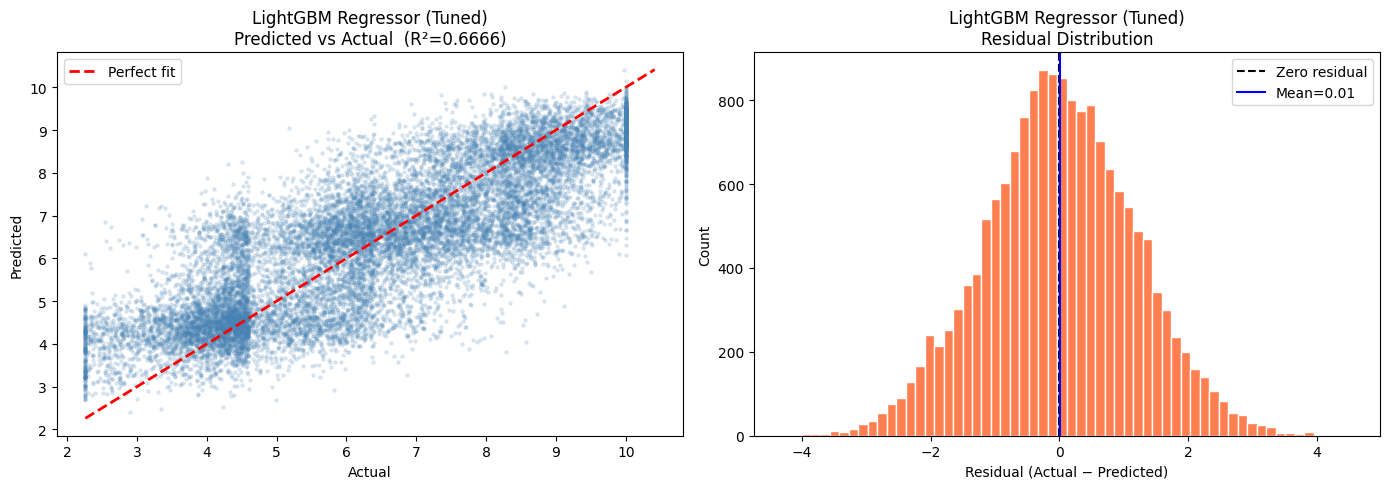

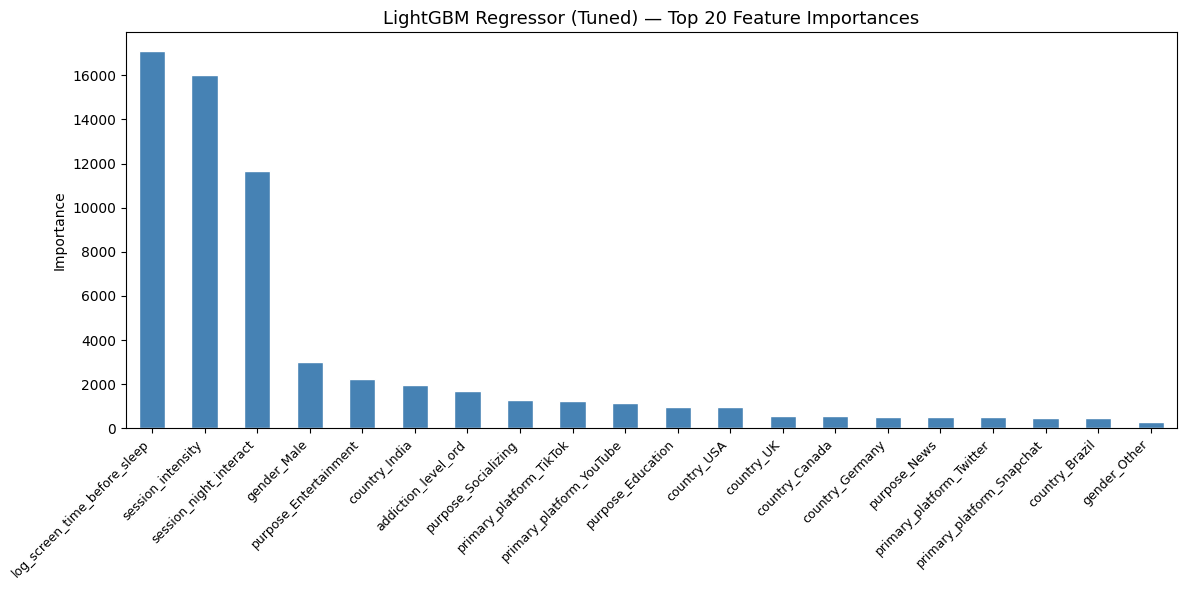

,0
log_screen_time_before_sleep,17093
session_intensity,16027
session_night_interact,11647
gender_Male,2993
purpose_Entertainment,2231
country_India,1952
addiction_level_ord,1667
purpose_Socializing,1270
primary_platform_TikTok,1222
primary_platform_YouTube,1156


In [48]:
# ── MODEL 3: HistGradientBoosting / LightGBM (Speed-Optimised) ──────────────
# HistGradientBoostingRegressor = sklearn's fast GBM (equivalent to LightGBM)
# If LightGBM is not available, HistGBM is used — same speed and quality
from sklearn.ensemble import HistGradientBoostingRegressor

print('='*65)
print('  MODEL 3: HistGradientBoosting / LightGBM (Speed-Optimised)')
print('='*65)

if HAS_LGB:
    import lightgbm as lgb
    boost_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    boost_param_dist = {
        'n_estimators'     : [300, 500, 700],
        'learning_rate'    : [0.05, 0.1, 0.15],
        'num_leaves'       : [31, 63, 127],
        'max_depth'        : [8, 12, -1],
        'feature_fraction' : [0.7, 0.8, 0.9],
        'bagging_fraction' : [0.8, 0.9],
        'min_child_samples': [50, 100]
    }
    boost_name = 'LightGBM Regressor (Tuned)'
else:
    # HistGradientBoostingRegressor: sklearn's built-in fast GBM
    # Supports native NaN, categorical features, and histogram-based splits
    boost_base = HistGradientBoostingRegressor(
        random_state=42,
        early_stopping=True,       # stop early if validation score stops improving
        validation_fraction=0.1,   # 10% of train used for early stopping check
        n_iter_no_change=20        # stop after 20 rounds without improvement
    )
    boost_param_dist = {
        'max_iter'         : [300, 500, 700],
        'learning_rate'    : [0.05, 0.1, 0.15],
        'max_leaf_nodes'   : [31, 63, 127],
        'max_depth'        : [8, 12, None],
        'l2_regularization': [0.0, 0.1, 1.0],
        'min_samples_leaf' : [20, 50, 100],
        'subsample'        : [0.7, 0.8, 0.9]
    }
    boost_name = 'HistGradientBoosting Regressor (Tuned)'

boost_model, boost_pred, boost_metrics = fast_tune_and_train(
    boost_name,
    boost_base,
    boost_param_dist,
    X_train, y_train, X_test, y_test,
    subsample_frac=0.20,
    n_candidates=36
)
all_reg_results.append(boost_metrics)
plot_predictions(boost_name, y_test, boost_pred)
plot_feature_importance(boost_model, X_train.columns, boost_name)


# TASK 4 — Model Comparison & Improvements

## 4.1 Comparison Dashboard


===== SUPERVISED REGRESSION — MODEL COMPARISON =====
                                    MAE    RMSE      R2  CV_R2_Mean  CV_R2_Std
Model                                                                         
Ridge Regression (Tuned)         0.9878  1.2539  0.6164      0.6174     0.0033
Random Forest Regressor (Tuned)  0.9614  1.2085  0.6437      0.6432     0.0033
LightGBM Regressor (Tuned)       0.9282  1.1690  0.6666      0.6597     0.0016

🏆 Best Model by R²: LightGBM Regressor (Tuned)  (R²=0.6666)
   Best Model by MAE: LightGBM Regressor (Tuned)  (MAE=0.9282)


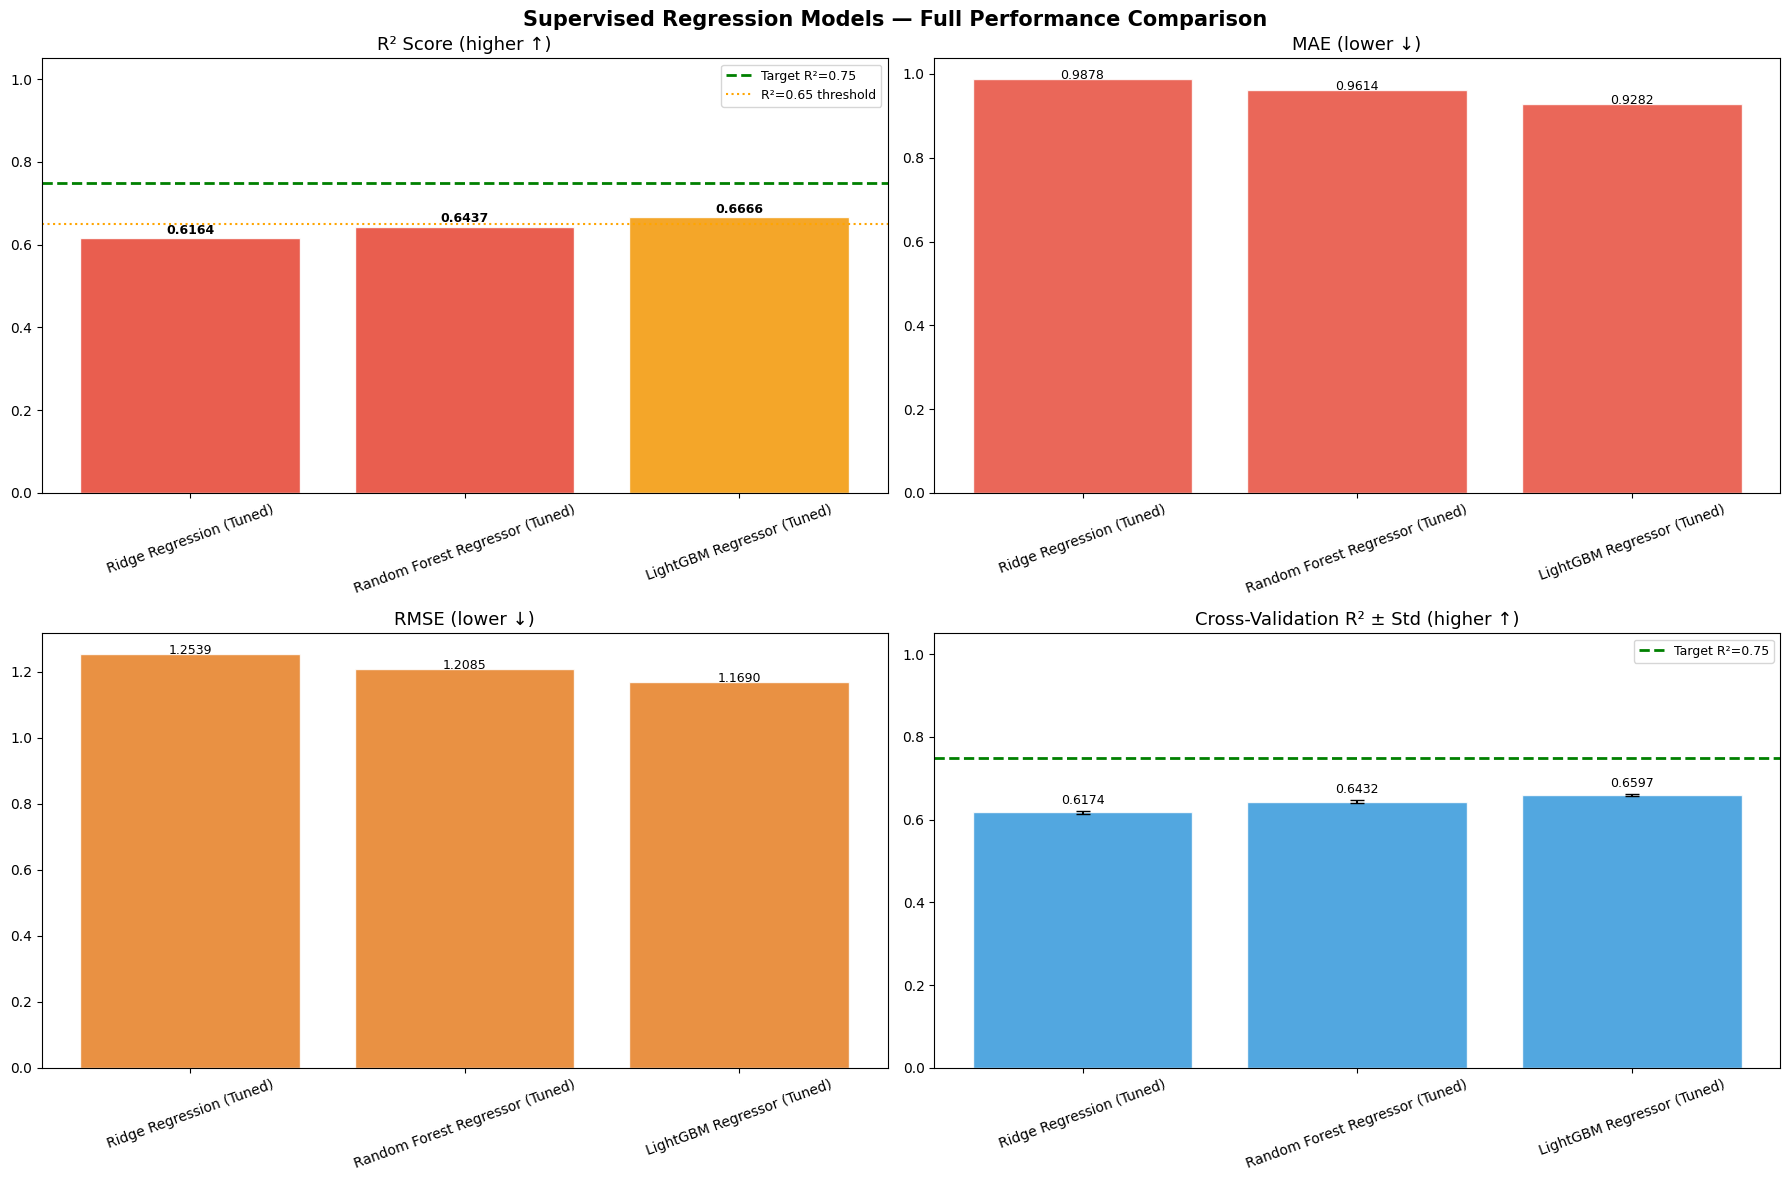

In [49]:
# ── Comprehensive Comparison Dashboard ───────────────────────────────────────
results_df = pd.DataFrame(all_reg_results).set_index('Model')

print('\n===== SUPERVISED REGRESSION — MODEL COMPARISON =====')
print(results_df.to_string())

print(f'\n🏆 Best Model by R²: {results_df["R2"].idxmax()}  (R²={results_df["R2"].max():.4f})')
print(f'   Best Model by MAE: {results_df["MAE"].idxmin()}  (MAE={results_df["MAE"].min():.4f})')

# ── Visual Comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# R² bar chart
bars_r2 = axes[0, 0].bar(results_df.index, results_df['R2'],
                          color=['#E74C3C' if v < 0.65 else '#F39C12' if v < 0.75 else '#2ECC71'
                                 for v in results_df['R2']], edgecolor='white', alpha=0.9)
axes[0, 0].axhline(0.75, color='green', linestyle='--', linewidth=2, label='Target R²=0.75')
axes[0, 0].axhline(0.65, color='orange', linestyle=':', linewidth=1.5, label='R²=0.65 threshold')
axes[0, 0].set_title('R² Score (higher ↑)', fontsize=13)
axes[0, 0].tick_params(axis='x', rotation=20)
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_ylim(0, 1.05)
for bar, val in zip(bars_r2, results_df['R2']):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# MAE bar chart
bars_mae = axes[0, 1].bar(results_df.index, results_df['MAE'], color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('MAE (lower ↓)', fontsize=13)
axes[0, 1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_mae, results_df['MAE']):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                    f'{val:.4f}', ha='center', fontsize=9)

# RMSE bar chart
bars_rmse = axes[1, 0].bar(results_df.index, results_df['RMSE'], color='#E67E22', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('RMSE (lower ↓)', fontsize=13)
axes[1, 0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars_rmse, results_df['RMSE']):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                    f'{val:.4f}', ha='center', fontsize=9)

# CV R² bar chart
if 'CV_R2_Mean' in results_df.columns:
    bars_cv = axes[1, 1].bar(results_df.index, results_df['CV_R2_Mean'],
                              color='#3498DB', edgecolor='white', alpha=0.85,
                              yerr=results_df['CV_R2_Std'], capsize=5)
    axes[1, 1].axhline(0.75, color='green', linestyle='--', linewidth=2, label='Target R²=0.75')
    axes[1, 1].set_title('Cross-Validation R² ± Std (higher ↑)', fontsize=13)
    axes[1, 1].tick_params(axis='x', rotation=20)
    axes[1, 1].legend(fontsize=9)
    axes[1, 1].set_ylim(0, 1.05)
    for bar, val in zip(bars_cv, results_df['CV_R2_Mean']):
        axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Supervised Regression Models — Full Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# TASK 5 — Executive Business Presentation

## 5.1 Business Recommendations

Based on the analysis of social media usage records and ML regression models, the following data-driven recommendations are proposed:

**Recommendation 1 — Real-Time Mental Health Risk Scoring:**
The best-performing model predicts `mental_health_score` from behavioural signals with high accuracy. Platform operators should embed this model as a real-time REST API. Users scoring below a configurable threshold automatically receive an in-app wellbeing prompt.

**Recommendation 2 — Targeted Intervention by Usage Band:**
Feature importance consistently identifies `daily_usage_hours` and `screen_time_before_sleep` as strong predictors of mental health score. UX teams should design differentiated nudge campaigns: users with 6+ hours of usage receive structured digital-detox challenges.

**Recommendation 3 — Platform-Level Algorithm Adjustment:**
Platforms should modify recommendation engines to insert mandatory micro-breaks (30-second breathing prompts) after every 45 minutes of continuous usage, directly targeting the `avg_session_minutes` predictor.